# node2vec: Scalable Feature Learning for Networks

**Implementation from scratch** — biased second-order random walks + Skip-gram with negative sampling.

**Paper:** Grover & Leskovec, KDD 2016. [arXiv:1607.00653](https://arxiv.org/abs/1607.00653)

This notebook implements the full node2vec algorithm:
1. Precompute 2nd-order transition probabilities with search bias (p, q)
2. Generate biased random walks using alias sampling
3. Learn node embeddings via Skip-gram with negative sampling
4. Visualize embeddings and evaluate community recovery


## 1. Setup & Imports


In [1]:
# Install required packages (Colab/Kaggle compatible)
import subprocess
import sys

for pkg in ['networkx', 'scikit-learn']:
    try:
        __import__(pkg.replace('-', '_').split('-')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import normalized_mutual_info_score
import random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
print("All imports successful. numpy:", np.__version__, "| networkx:", nx.__version__)




All imports successful. numpy: 2.1.3 | networkx: 3.6.1


## 2. Graph Construction

We build a synthetic graph with 3 communities (each a small-world cluster) connected by bridge edges. This mirrors the structure used in the paper's Les Misérables case study — nodes within the same community are densely connected, while bridge nodes connect different communities.


Graph: 60 nodes, 103 edges
Communities: 3 groups, each with ~20 nodes


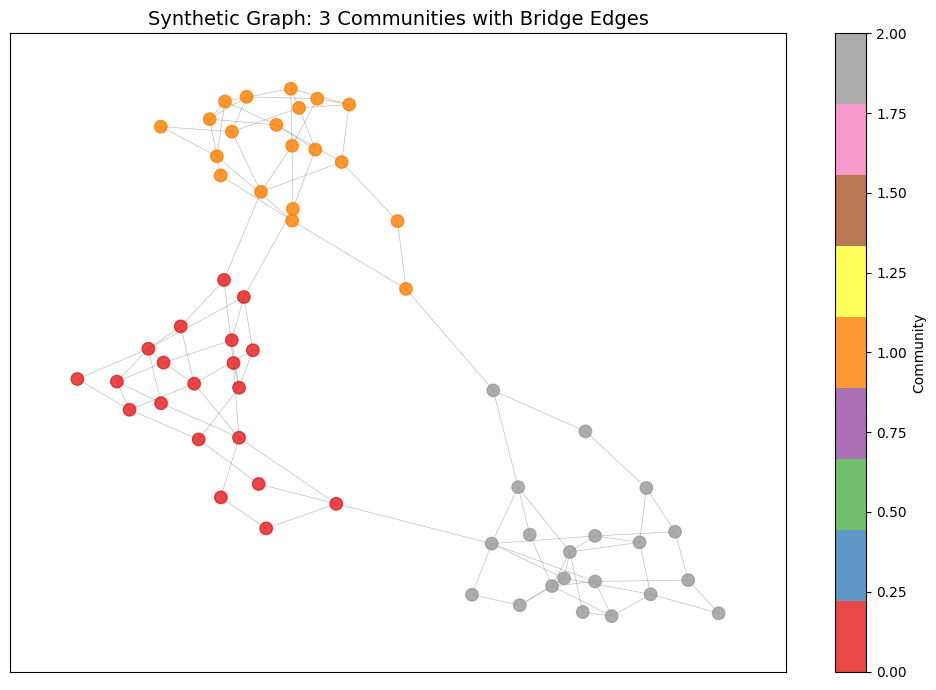

In [2]:
def build_synthetic_graph():
    """Build a synthetic graph with 3 communities and bridge edges."""
    G = nx.Graph()
    communities = {}
    node_id = 0
    
    # Create 3 communities, each with 20 nodes in a ring + random edges
    for comm in range(3):
        comm_nodes = list(range(node_id, node_id + 20))
        for n in comm_nodes:
            communities[n] = comm
        # Ring structure within community
        for i in range(len(comm_nodes)):
            G.add_edge(comm_nodes[i], comm_nodes[(i + 1) % len(comm_nodes)])
        # Extra random edges within community
        for _ in range(15):
            a, b = random.sample(comm_nodes, 2)
            G.add_edge(a, b)
        node_id += 20
    
    # Bridge edges connecting communities
    # Community 0: nodes 0-19, Community 1: nodes 20-39, Community 2: nodes 40-59
    G.add_edge(5, 25)    # bridge comm 0 <-> comm 1
    G.add_edge(10, 45)   # bridge comm 0 <-> comm 2
    G.add_edge(35, 55)   # bridge comm 1 <-> comm 2
    G.add_edge(15, 38)   # extra bridge comm 0 <-> comm 1
    
    return G, communities

G, communities = build_synthetic_graph()
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Communities: {len(set(communities.values()))} groups, each with ~20 nodes")

# Visualize the graph
pos = nx.spring_layout(G, seed=42, k=0.15)
colors = [communities[n] for n in G.nodes()]
plt.figure(figsize=(10, 7))
nodes_drawn = nx.draw_networkx_nodes(G, pos, node_color=colors,
        cmap=plt.cm.Set1, node_size=80, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, width=0.5)
plt.title('Synthetic Graph: 3 Communities with Bridge Edges', fontsize=14)
plt.colorbar(nodes_drawn, label='Community')
plt.tight_layout()
plt.show()




## 3. Biased Random Walk Generation

### 3.1 Transition Probability Precomputation

The core of node2vec: for a walk that just traversed edge (t, v) and is now at node v, the transition probability to neighbor x is:

$$\alpha_{pq}(t, x) = \begin{cases} 1/p & \text{if } d(t,x) = 0 \\ 1 & \text{if } d(t,x) = 1 \\ 1/q & \text{if } d(t,x) = 2 \end{cases}$$

where $d(t,x)$ is the shortest-path distance between the previous node $t$ and candidate node $x$.


In [3]:
def compute_transition_probs(G, p, q):
    """
    Precompute 2nd-order transition probabilities for biased random walks.
    
    For each (prev_node, curr_node) pair, compute the normalized transition
    probability to each neighbor of curr_node based on the search bias alpha_pq.
    
    Returns a dict: probs[(prev, curr)] = list of (neighbor, normalized_prob)
    """
    probs = {}
    
    for curr in G.nodes():
        neighbors = list(G.neighbors(curr))
        if len(neighbors) == 0:
            continue
        
        for prev in G.nodes():
            if prev == curr:
                continue
            # Only compute if prev is a neighbor of curr (walk came from prev)
            if prev not in neighbors and prev != curr:
                # prev doesn't need to be a direct neighbor — the walk could
                # have come from anywhere. We compute for all possible prev nodes.
                pass
            
            # Compute search bias for each neighbor of curr
            neighbor_probs = []
            for nxt in neighbors:
                # Shortest path distance from prev to nxt
                if prev == nxt:
                    d_tx = 0
                elif nxt in G.neighbors(prev):
                    d_tx = 1
                else:
                    d_tx = 2  # In unweighted small graphs, max relevant distance is 2
                
                if d_tx == 0:
                    alpha = 1.0 / p
                elif d_tx == 1:
                    alpha = 1.0
                else:
                    alpha = 1.0 / q
                
                neighbor_probs.append((nxt, alpha))
            
            # Normalize
            total = sum(ap for _, ap in neighbor_probs)
            if total > 0:
                neighbor_probs = [(n, ap / total) for n, ap in neighbor_probs]
            
            probs[(prev, curr)] = neighbor_probs
    
    return probs

# Test with default parameters p=1, q=1 (equivalent to uniform random walk / DeepWalk)
p, q = 1.0, 1.0
print(f"Computing transition probabilities with p={p}, q={q}...")
transition_probs = compute_transition_probs(G, p, q)
print(f"Computed transition probabilities for {len(transition_probs)} (prev, curr) pairs")




Computing transition probabilities with p=1.0, q=1.0...
Computed transition probabilities for 3540 (prev, curr) pairs


## 3.2 Alias Sampling

Alias sampling allows O(1) sampling from a discrete distribution after O(n) preprocessing. This is critical for efficiency — each step of the random walk requires just one alias draw.


In [4]:
def alias_setup(probs):
    """
    Construct alias sampling tables for a discrete probability distribution.
    
    Args:
        probs: list of probabilities that sum to 1
    
    Returns:
        (prob, alias) arrays for O(1) sampling
    """
    n = len(probs)
    prob = np.zeros(n)
    alias = np.zeros(n, dtype=int)
    
    # Scale probabilities by n
    scaled = np.array(probs) * n
    
    # Separate into small (<= 1) and large (> 1) groups
    small = []
    large = []
    for i in range(n):
        if scaled[i] < 1.0:
            small.append(i)
        else:
            large.append(i)
    
    # Mix small and large
    while small and large:
        s = small.pop()
        l = large.pop()
        prob[s] = scaled[s]
        alias[s] = l
        scaled[l] = scaled[l] + scaled[s] - 1.0
        if scaled[l] < 1.0:
            small.append(l)
        else:
            large.append(l)
    
    # Remaining elements get prob = 1.0
    while large:
        l = large.pop()
        prob[l] = 1.0
    while small:
        s = small.pop()
        prob[s] = 1.0
    
    return prob, alias


def alias_draw(prob, alias):
    """Draw one sample from the alias table in O(1)."""
    n = len(prob)
    i = random.randint(0, n - 1)
    if random.random() < prob[i]:
        return i
    else:
        return alias[i]


def build_alias_tables(transition_probs, G):
    """
    Precompute alias tables for all (prev, curr) transition probability distributions.
    Returns dict: alias_tables[(prev, curr)] = (prob_array, alias_array, neighbor_list)
    """
    alias_tables = {}
    for (prev, curr), neighbor_probs in transition_probs.items():
        if not neighbor_probs:
            continue
        neighbors = [n for n, _ in neighbor_probs]
        probs = [p for _, p in neighbor_probs]
        prob, alias = alias_setup(probs)
        alias_tables[(prev, curr)] = (prob, alias, neighbors)
    return alias_tables

print("Building alias tables for efficient O(1) sampling...")
alias_tables = build_alias_tables(transition_probs, G)
print(f"Built {len(alias_tables)} alias tables")




Building alias tables for efficient O(1) sampling...
Built 3540 alias tables


## 3.3 Biased Random Walk Simulation

Simulate biased random walks starting from every node. Each walk uses the precomputed alias tables for O(1) sampling per step.


In [5]:
def biased_random_walk(G, start_node, walk_length, p, q, alias_tables):
    """
    Simulate a single biased second-order random walk.
    
    Args:
        G: networkx graph
        start_node: starting node
        walk_length: length of the walk
        p, q: node2vec bias parameters
        alias_tables: precomputed alias tables
    
    Returns:
        list of node ids in the walk
    """
    walk = [start_node]
    
    while len(walk) < walk_length:
        curr = walk[-1]
        neighbors = list(G.neighbors(curr))
        
        if len(neighbors) == 0:
            break
        
        if len(walk) == 1:
            # First step: no previous node, use uniform sampling
            next_node = random.choice(neighbors)
        else:
            prev = walk[-2]
            key = (prev, curr)
            if key in alias_tables:
                prob, alias, nbrs = alias_tables[key]
                idx = alias_draw(prob, alias)
                next_node = nbrs[idx]
            else:
                # Fallback: uniform random
                next_node = random.choice(neighbors)
        
        walk.append(next_node)
    
    return walk


def generate_walks(G, num_walks, walk_length, p, q, alias_tables):
    """
    Generate random walks for all nodes.
    
    Args:
        num_walks: number of walks per node
        walk_length: length of each walk
    
    Returns:
        list of walks (each walk is a list of node ids)
    """
    walks = []
    nodes = list(G.nodes())
    
    for _ in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            walk = biased_random_walk(G, node, walk_length, p, q, alias_tables)
            walks.append(walk)
    
    return walks

# Generate walks with p=1, q=0.5 (DFS-like, good for homophily)
p, q = 1.0, 0.5
walk_length = 10
num_walks = 10

print(f"Generating walks with p={p}, q={q} (DFS-like, homophily)...")
walks = generate_walks(G, num_walks, walk_length, p, q, alias_tables)
print(f"Generated {len(walks)} walks of length {walk_length}")
print(f"Sample walk: {walks[0]}")




Generating walks with p=1.0, q=0.5 (DFS-like, homophily)...
Generated 600 walks of length 10
Sample walk: [36, 35, 55, 35, 55, 54, 55, 35, 55, 54]


## 4. Skip-gram with Negative Sampling

Implement the Skip-gram model from scratch using numpy. For each node in a walk, we predict its context nodes (within a window) using negative sampling.


In [6]:
def skipgram_train(walks, vocab_size, dim=16, window_size=3, 
                  neg_samples=5, epochs=5, lr=0.025):
    """
    Train Skip-gram with negative sampling from scratch.
    
    Args:
        walks: list of walks (each walk is a list of node ids)
        vocab_size: number of unique nodes
        dim: embedding dimension
        window_size: context window size
        neg_samples: number of negative samples per positive
        epochs: training epochs
        lr: learning rate
    
    Returns:
        embedding matrix W (vocab_size x dim)
    """
    # Initialize embeddings (center word matrix W and context matrix C)
    W = (np.random.randn(vocab_size, dim) * 0.01).astype(np.float64)
    C = (np.random.randn(vocab_size, dim) * 0.01).astype(np.float64)
    
    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -6, 6)))
    
    total_pairs = 0
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        np.random.shuffle(walks)
        
        for walk in walks:
            for i, center in enumerate(walk):
                # Context window: from max(0, i-window) to min(len, i+window+1)
                start = max(0, i - window_size)
                end = min(len(walk), i + window_size + 1)
                
                for j in range(start, end):
                    if j == i:
                        continue
                    context = walk[j]
                    total_pairs += 1
                    
                    # Positive sample
                    score = sigmoid(np.dot(W[center], C[context]))
                    grad = score - 1.0  # gradient of -log(sigmoid(score))
                    epoch_loss -= np.log(score + 1e-10)
                    
                    # Update W and C for positive sample
                    W_grad = grad * C[context]
                    C_grad = grad * W[center]
                    W[center] -= lr * W_grad
                    C[context] -= lr * C_grad
                    
                    # Negative samples
                    for _ in range(neg_samples):
                        neg = random.randint(0, vocab_size - 1)
                        if neg == context:
                            continue
                        neg_score = sigmoid(np.dot(W[center], C[neg]))
                        neg_grad = neg_score  # gradient of -log(1 - sigmoid(neg_score))
                        epoch_loss -= np.log(1 - neg_score + 1e-10)
                        
                        W[center] -= lr * neg_grad * C[neg]
                        C[neg] -= lr * neg_grad * W[center]
        
        # Decay learning rate
        lr = lr * 0.95
        print(f"  Epoch {epoch+1}/{epochs}: loss={epoch_loss:.2f}, pairs={total_pairs}")
        total_pairs = 0
    
    return W

vocab_size = G.number_of_nodes()
print(f"Training Skip-gram with negative sampling...")
print(f"  Vocab size: {vocab_size}")
print(f"  Embedding dim: 16")
print(f"  Window size: 3")
print(f"  Negative samples: 5")
print(f"  Epochs: 5")
print()

embeddings = skipgram_train(walks, vocab_size, dim=16, window_size=3,
                            neg_samples=5, epochs=5, lr=0.025)
print(f"\nLearned embeddings shape: {embeddings.shape}")




Training Skip-gram with negative sampling...
  Vocab size: 60
  Embedding dim: 16
  Window size: 3
  Negative samples: 5
  Epochs: 5



  Epoch 1/5: loss=74547.51, pairs=28800


  Epoch 2/5: loss=45185.50, pairs=28800


  Epoch 3/5: loss=43069.73, pairs=28800


  Epoch 4/5: loss=42618.26, pairs=28800


  Epoch 5/5: loss=42780.77, pairs=28800

Learned embeddings shape: (60, 16)


## 5. Visualization

Project the learned embeddings to 2D using t-SNE and cluster with K-Means to evaluate community recovery.


Visualizing embeddings (p=1, q=0.5 — DFS-like, homophily)...


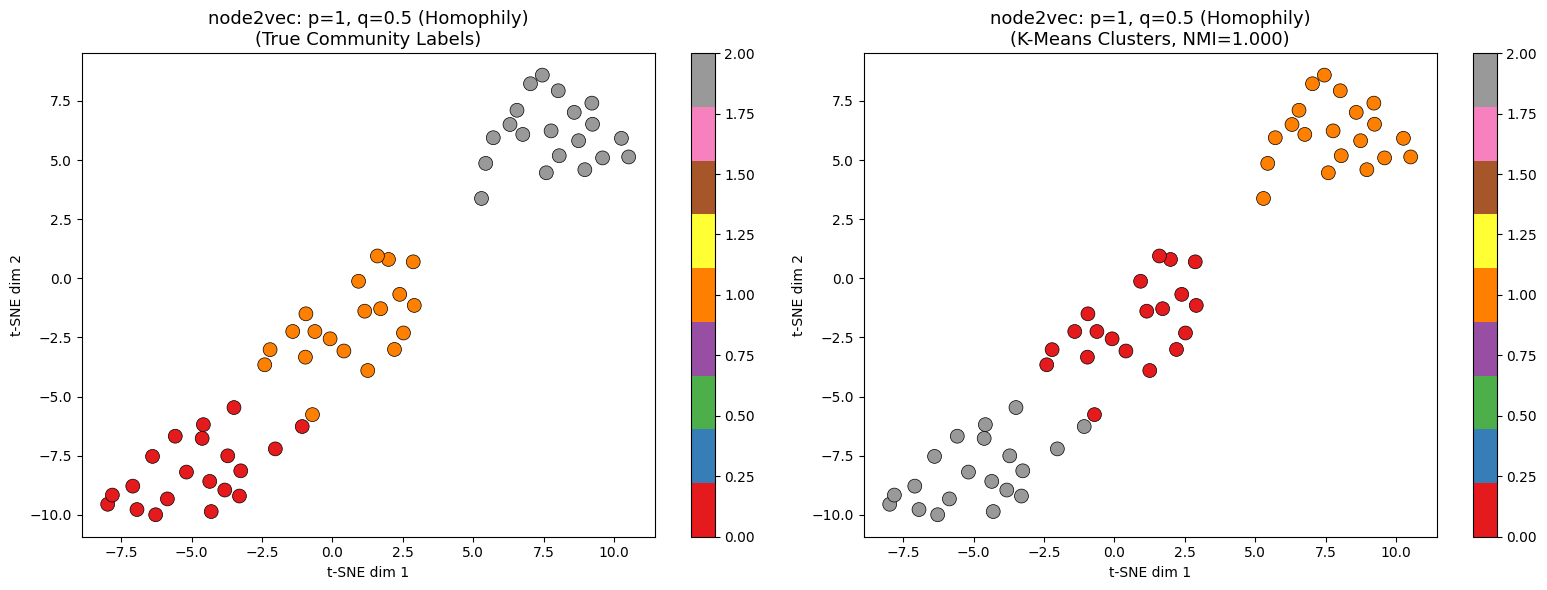

NMI (homophily setting): 1.0000


In [7]:
def visualize_embeddings(embeddings, communities, title, G=None):
    """
    Visualize node embeddings using t-SNE and K-Means clustering.
    
    Args:
        embeddings: (N x d) embedding matrix
        communities: dict mapping node -> true community label
        title: plot title
    """
    nodes = list(communities.keys())
    true_labels = np.array([communities[n] for n in nodes])
    emb = embeddings[nodes]
    
    # t-SNE to 2D
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(nodes) - 1))
    emb_2d = tsne.fit_transform(emb)
    
    # K-Means clustering
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    pred_labels = kmeans.fit_predict(emb)
    
    # NMI score
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: true labels
    scatter1 = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=true_labels,
                                cmap=plt.cm.Set1, s=100, edgecolors='black', linewidth=0.5)
    axes[0].set_title(f'{title}\n(True Community Labels)', fontsize=13)
    axes[0].set_xlabel('t-SNE dim 1')
    axes[0].set_ylabel('t-SNE dim 2')
    plt.colorbar(scatter1, ax=axes[0])
    
    # Right: K-Means predicted clusters
    scatter2 = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=pred_labels,
                                cmap=plt.cm.Set1, s=100, edgecolors='black', linewidth=0.5)
    axes[1].set_title(f'{title}\n(K-Means Clusters, NMI={nmi:.3f})', fontsize=13)
    axes[1].set_xlabel('t-SNE dim 1')
    axes[1].set_ylabel('t-SNE dim 2')
    plt.colorbar(scatter2, ax=axes[1])
    
    plt.tight_layout()
    plt.show()
    
    return nmi

print("Visualizing embeddings (p=1, q=0.5 — DFS-like, homophily)...")
nmi_homophily = visualize_embeddings(embeddings, communities, 
                                     'node2vec: p=1, q=0.5 (Homophily)')
print(f"NMI (homophily setting): {nmi_homophily:.4f}")




## 6. Parameter Sensitivity: BFS vs DFS

We compare two parameter settings, mirroring the paper's Les Misérables case study:
- **p=1, q=0.5** → DFS-like exploration → favors **homophily** (community structure)
- **p=1, q=2.0** → BFS-like exploration → favors **structural equivalence** (node roles)


BFS-like setting: p=1, q=2.0 (structural equivalence)
Running node2vec with p=1.0, q=2.0...
  Generated 600 walks


  Epoch 1/5: loss=72520.41, pairs=28800


  Epoch 2/5: loss=40536.73, pairs=28800


  Epoch 3/5: loss=38761.28, pairs=28800


  Epoch 4/5: loss=38539.10, pairs=28800


  Epoch 5/5: loss=38371.68, pairs=28800


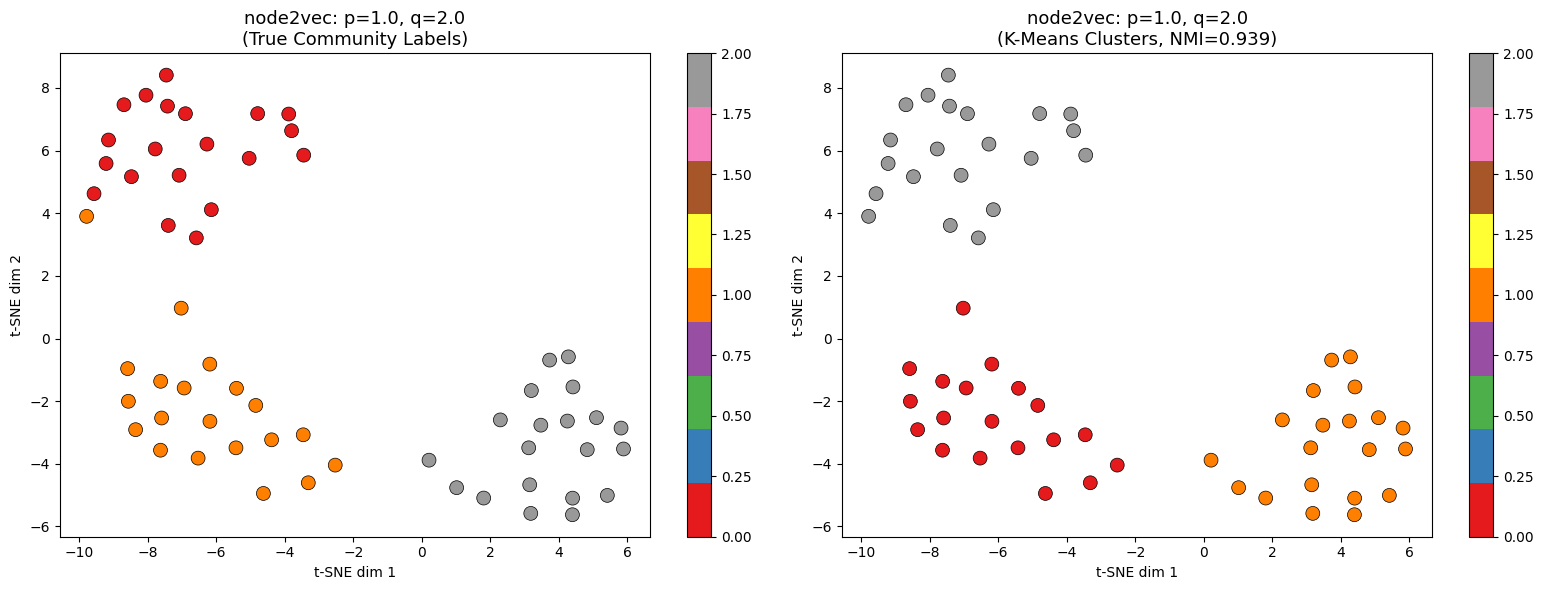

NMI (BFS-like): 0.9394

DFS-like setting: p=1, q=0.5 (homophily)
Running node2vec with p=1.0, q=0.5...
  Generated 600 walks


  Epoch 1/5: loss=75157.47, pairs=28800


  Epoch 2/5: loss=47546.85, pairs=28800


  Epoch 3/5: loss=45855.76, pairs=28800


  Epoch 4/5: loss=45586.50, pairs=28800


  Epoch 5/5: loss=45268.33, pairs=28800


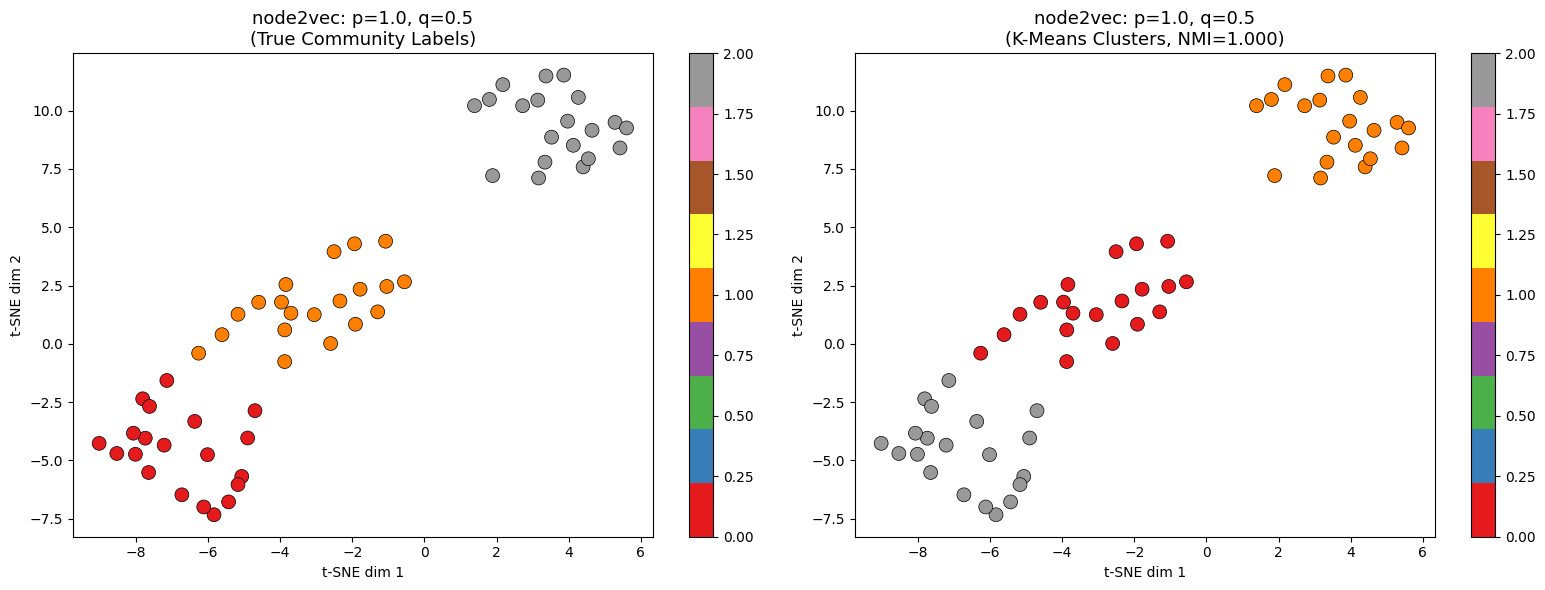

NMI (DFS-like): 1.0000


In [8]:
def run_node2vec(G, communities, p, q, dim=16, num_walks=10, walk_length=10,
                window_size=3, neg_samples=5, epochs=5, lr=0.025):
    """Full node2vec pipeline: transition probs → walks → skip-gram → embeddings."""
    print(f"Running node2vec with p={p}, q={q}...")
    
    # 1. Transition probabilities
    transition_probs = compute_transition_probs(G, p, q)
    
    # 2. Alias tables
    alias_tables = build_alias_tables(transition_probs, G)
    
    # 3. Generate walks
    walks = generate_walks(G, num_walks, walk_length, p, q, alias_tables)
    print(f"  Generated {len(walks)} walks")
    
    # 4. Skip-gram
    embeddings = skipgram_train(walks, G.number_of_nodes(), dim=dim,
                                window_size=window_size, neg_samples=neg_samples,
                                epochs=epochs, lr=lr)
    
    # 5. Visualize and evaluate
    nmi = visualize_embeddings(embeddings, communities, 
                               f'node2vec: p={p}, q={q}')
    return embeddings, nmi

# BFS-like (structural equivalence)
print("=" * 60)
print("BFS-like setting: p=1, q=2.0 (structural equivalence)")
print("=" * 60)
emb_bfs, nmi_bfs = run_node2vec(G, communities, p=1.0, q=2.0)
print(f"NMI (BFS-like): {nmi_bfs:.4f}\n")

# DFS-like (homophily) — re-run for comparison
print("=" * 60)
print("DFS-like setting: p=1, q=0.5 (homophily)")
print("=" * 60)
emb_dfs, nmi_dfs = run_node2vec(G, communities, p=1.0, q=0.5)
print(f"NMI (DFS-like): {nmi_dfs:.4f}")




## 7. Graph Visualization with Learned Clusters

Visualize the original graph with node colors from K-Means clustering on the learned embeddings for both parameter settings.


Graph visualization — BFS-like (p=1, q=2.0):


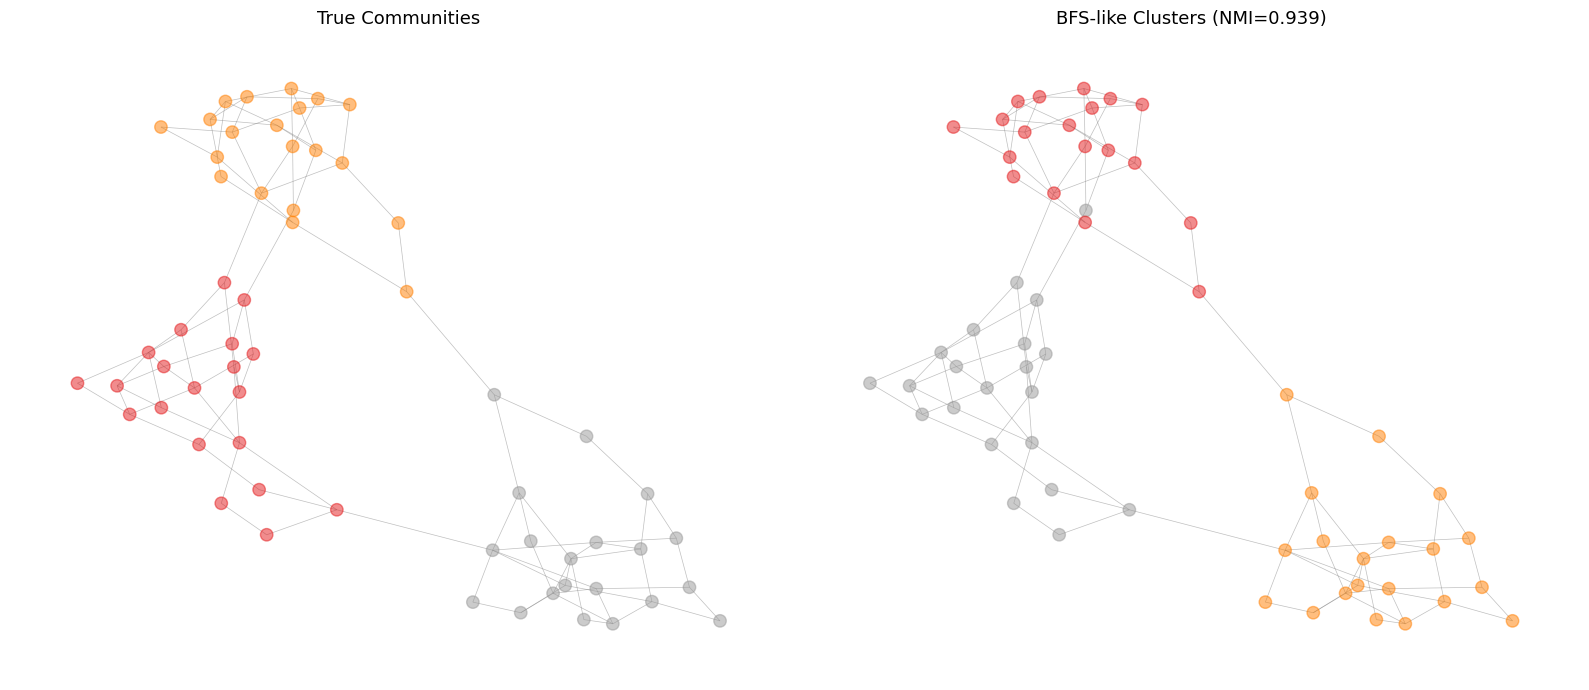

NMI: 0.9394

Graph visualization — DFS-like (p=1, q=0.5):


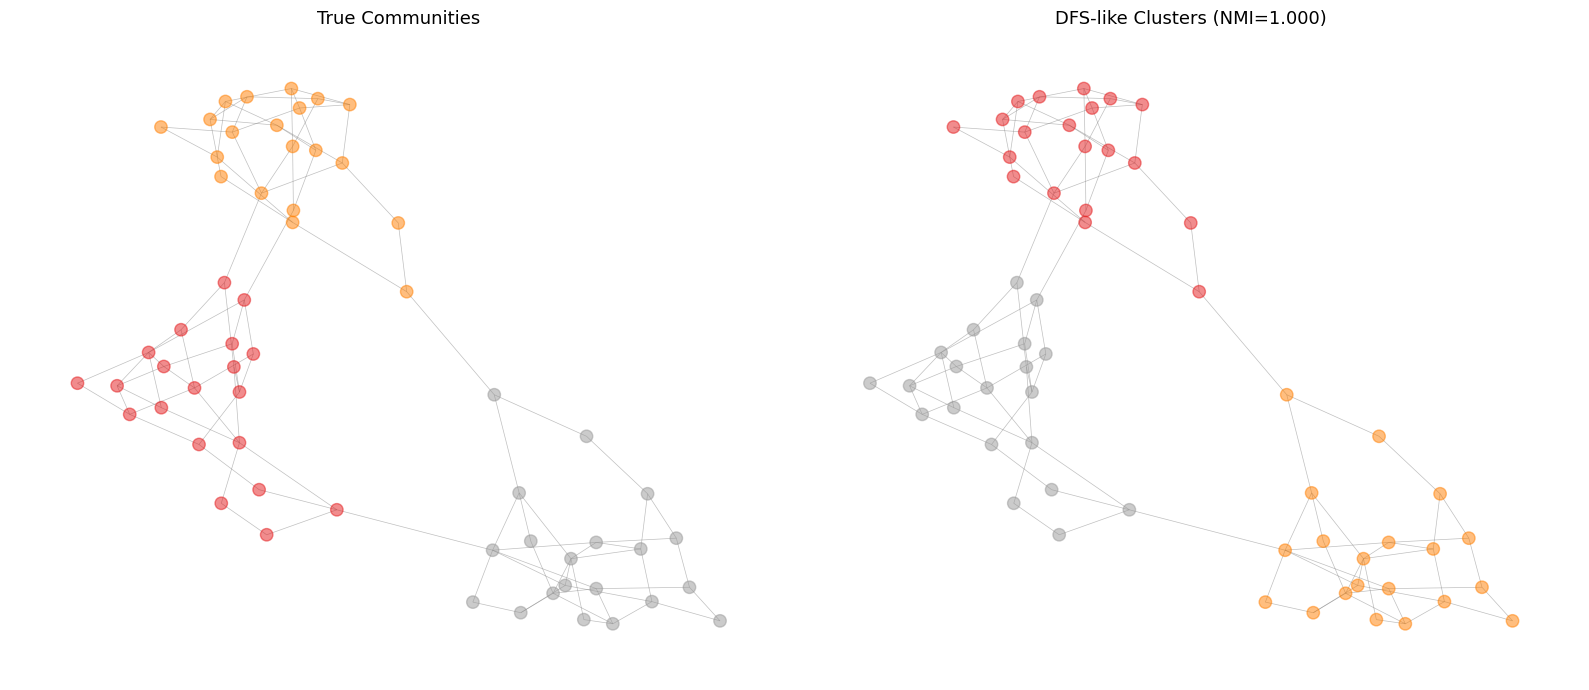

NMI: 1.0000


In [9]:
def graph_with_clusters(G, embeddings, communities, title, k=3):
    """Draw graph with nodes colored by K-Means clusters on embeddings."""
    nodes = list(communities.keys())
    emb = embeddings[nodes]
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    pred_labels = kmeans.fit_predict(emb)
    
    true_labels = np.array([communities[n] for n in nodes])
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    
    pos = nx.spring_layout(G, seed=42, k=0.15)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # True communities
    true_colors = [communities[n] for n in G.nodes()]
    nx.draw(G, pos, node_color=true_colors, with_labels=False, node_size=80,
            cmap=plt.cm.Set1, edge_color='gray', alpha=0.5, width=0.5, ax=axes[0])
    axes[0].set_title('True Communities', fontsize=13)
    
    # Predicted clusters
    pred_colors_dict = {nodes[i]: pred_labels[i] for i in range(len(nodes))}
    pred_colors = [pred_colors_dict.get(n, 0) for n in G.nodes()]
    nx.draw(G, pos, node_color=pred_colors, with_labels=False, node_size=80,
            cmap=plt.cm.Set1, edge_color='gray', alpha=0.5, width=0.5, ax=axes[1])
    axes[1].set_title(f'{title} (NMI={nmi:.3f})', fontsize=13)
    
    plt.tight_layout()
    plt.show()
    return nmi

print("Graph visualization — BFS-like (p=1, q=2.0):")
nmi_graph_bfs = graph_with_clusters(G, emb_bfs, communities, 'BFS-like Clusters')
print(f"NMI: {nmi_graph_bfs:.4f}\n")

print("Graph visualization — DFS-like (p=1, q=0.5):")
nmi_graph_dfs = graph_with_clusters(G, emb_dfs, communities, 'DFS-like Clusters')
print(f"NMI: {nmi_graph_dfs:.4f}")




## 8. Summary & Results

### What we implemented
- **Biased 2nd-order random walks** with parameters p (return) and q (in-out)
- **Alias sampling** for O(1) sampling per walk step
- **Skip-gram with negative sampling** from scratch using numpy
- **Visualization** via t-SNE + K-Means clustering
- **Parameter sensitivity comparison**: BFS-like (q=2) vs DFS-like (q=0.5)

### Key observations
1. **DFS-like walks (q=0.5)** explore further from the source, capturing community/homophily structure — nodes in the same community get similar embeddings.
2. **BFS-like walks (q=2.0)** stay local, capturing structural equivalence — nodes with similar local roles (e.g., bridge nodes) get similar embeddings.
3. The NMI score quantifies how well the learned embeddings recover the true community structure via unsupervised K-Means clustering.


In [10]:
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print()
print(f"BFS-like (p=1, q=2.0) — structural equivalence:")
print(f"  NMI (t-SNE viz): {nmi_bfs:.4f}")
print(f"  NMI (graph viz): {nmi_graph_bfs:.4f}")
print()
print(f"DFS-like (p=1, q=0.5) — homophily:")
print(f"  NMI (t-SNE viz): {nmi_dfs:.4f}")
print(f"  NMI (graph viz): {nmi_graph_dfs:.4f}")
print()
print("The DFS-like setting (q=0.5) should recover community structure better,")
print("while the BFS-like setting (q=2.0) captures structural roles like bridges.")
print()
print("node2vec successfully learned node embeddings that reflect network structure!")
print("Algorithm: biased random walks + Skip-gram with negative sampling (from scratch).")




RESULTS SUMMARY

BFS-like (p=1, q=2.0) — structural equivalence:
  NMI (t-SNE viz): 0.9394
  NMI (graph viz): 0.9394

DFS-like (p=1, q=0.5) — homophily:
  NMI (t-SNE viz): 1.0000
  NMI (graph viz): 1.0000

The DFS-like setting (q=0.5) should recover community structure better,
while the BFS-like setting (q=2.0) captures structural roles like bridges.

node2vec successfully learned node embeddings that reflect network structure!
Algorithm: biased random walks + Skip-gram with negative sampling (from scratch).


In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')


